# EDA for Lead Time Regression

Goal: check the prepared SQL export, validate the target and model features, and document the version-1 modeling decisions for the lead time regression pipeline.

This notebook is intentionally lean. It does not perform raw data cleaning. The enriched overlap dataset was already prepared by SQL.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.eda_regression_checks_utils import (
    categorical_target_summary,
    long_delay_summary,
    missingness_summary,
    split_summary_by_date,
    validate_no_missing_required_values,
    validate_positive_target,
    validate_required_columns,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "supply_chain_enriched_overlap.csv"
CONFIG_PATH = PROJECT_ROOT / "config" / "modeling.yaml"

TARGET = "lead_time_days"

NUMERIC_FEATURES = [
    "distance_km",
    "weight_mt",
    "fuel_price_index",
    "geopolitical_risk_score",
    "carrier_reliability_score",
    "copper__usd_per_mt",
]

CATEGORICAL_FEATURES = [
    "origin_port",
    "destination_port",
    "transport_mode",
    "product_category",
    "weather_condition",
]

EXCLUDED_COLUMNS = [
    "shipment_id",
    "date",
    "month",
    "lead_time_days",
    "disruption_occurred",
]

REQUIRED_COLUMNS = [TARGET, "date"] + NUMERIC_FEATURES + CATEGORICAL_FEATURES

## 1. Load data

Load the enriched overlap dataset exported by SQL. The `date` and `month` columns are parsed as dates for chronological checks and splitting.

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["date", "month"])

df.head()

,shipment_id,date,month,origin_port,destination_port,transport_mode,product_category,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,weather_condition,carrier_reliability_score,lead_time_days,disruption_occurred,copper__usd_per_mt
0,SC-10001,2024-04-24,2024-04-01,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,9464.43
1,SC-10002,2024-01-26,2024-01-01,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,8338.88
2,SC-10003,2024-10-08,2024-10-01,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,9533.99
3,SC-10004,2024-09-07,2024-09-01,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,9237.48
4,SC-10005,2024-08-16,2024-08-01,Rotterdam,Marseille,Rail,Automotive,2761.92,44.98,4.06,2.2,Rain,0.869,2.16,1,8971.96


## 2. Basic shape and missingness

Check that the dataset has the expected structure and that required modeling columns are complete.

In [4]:
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

display(df.dtypes.to_frame("dtype"))
display(missingness_summary(df))

Dataset shape: 2,455 rows x 16 columns


,dtype
shipment_id,object
date,datetime64[ns]
month,datetime64[ns]
origin_port,object
destination_port,object
transport_mode,object
product_category,object
distance_km,float64
weight_mt,float64
fuel_price_index,float64


,missing_count,missing_pct
shipment_id,0,0.0
date,0,0.0
month,0,0.0
origin_port,0,0.0
destination_port,0,0.0
transport_mode,0,0.0
product_category,0,0.0
distance_km,0,0.0
weight_mt,0,0.0
fuel_price_index,0,0.0


In [5]:
validate_required_columns(df, REQUIRED_COLUMNS)
validate_no_missing_required_values(df, REQUIRED_COLUMNS)

df[REQUIRED_COLUMNS].isna().sum().to_frame("missing_count")

,missing_count
lead_time_days,0
date,0
distance_km,0
weight_mt,0
fuel_price_index,0
geopolitical_risk_score,0
carrier_reliability_score,0
copper__usd_per_mt,0
origin_port,0
destination_port,0


**Interpretation.** The required target, date, numeric feature, and categorical feature columns are present and complete. The modeling pipeline can fail fast if these columns contain missing values.

## 3. Target check

Check whether `lead_time_days` is usable as a regression target and inspect its distribution.

In [6]:
validate_positive_target(df, TARGET)

df[TARGET].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame()

,lead_time_days
count,2455.000000
mean,18.976660
std,29.908269
min,0.500000
1%,0.500000
5%,0.500000
10%,0.600000
25%,2.160000
50%,8.170000
75%,21.210000


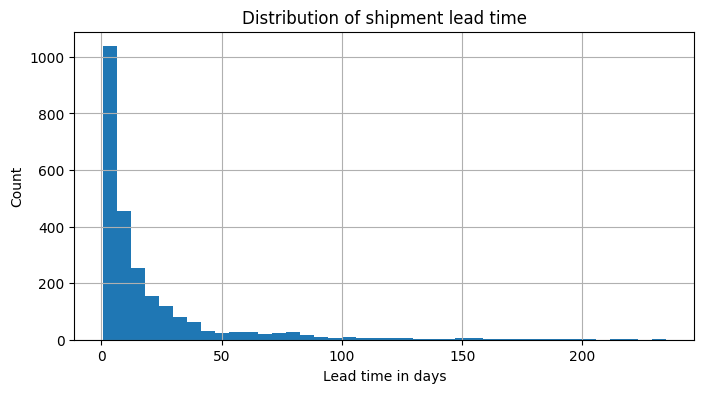

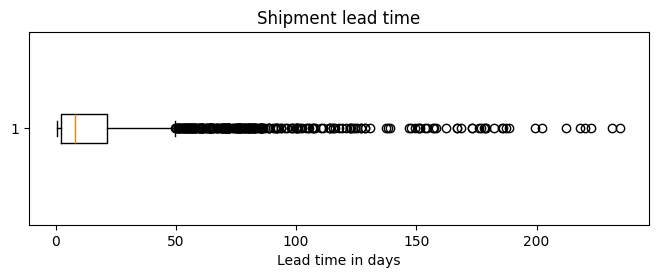

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df[TARGET].hist(bins=40, ax=ax)
ax.set_xlabel("Lead time in days")
ax.set_ylabel("Count")
ax.set_title("Distribution of shipment lead time")
plt.show()

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.boxplot(df[TARGET], vert=False)
ax.set_xlabel("Lead time in days")
ax.set_title("Shipment lead time")
plt.show()

### Long-delay diagnostic

Long delays are checked using the 90th percentile instead of IQR-based outlier removal. The goal is to understand whether the long-delay tail looks operationally plausible.

In [8]:
long_delay_threshold, long_delay_numeric = long_delay_summary(
    df=df,
    target_col=TARGET,
    numeric_cols=NUMERIC_FEATURES,
    quantile=0.90,
)

print(f"90th percentile lead-time threshold: {long_delay_threshold:.2f} days")
display(long_delay_numeric)

90th percentile lead-time threshold: 51.04 days


distance_km                                   weight_mt                              fuel_price_index                         \
                 count    median          mean       max     count   median        mean     max            count median      mean   max   
long_delay                                                                                                                                
False             2209   7090.85   7406.874559  14995.91      2209  241.210  244.559330  499.45             2209  2.840  2.856759  4.50   
True               246  10885.26  10598.088984  14959.14       246  243.965  247.310976  496.42              246  2.775  2.828902  4.46   

           geopolitical_risk_score                        carrier_reliability_score                         copper__usd_per_mt                        \
                             count median      mean   max                     count median      mean    max              count   median         mean   
long_delay                                                                                                                                             
False                         2209    5.0  4.968945  10.0                      2209  0.753  0.753446  1.000               2209  9237.48  9155.910326   
True                           246    5.5  5.354472  10.0                       246  0.757  0.759329  0.999                246  9237.48  9182.965854   

                     lead_time_days                            
                 max          count median       mean     max  
long_delay                                                     
False       10139.33           2209   7.08  10.701679   50.99  
True        10139.33            246  79.16  93.283293  234.84

In [9]:
df_long = df.assign(long_delay=df[TARGET] >= long_delay_threshold)

for col in ["transport_mode", "weather_condition"]:
    print(f"Long-delay share by {col}")
    display(
        pd.crosstab(
            df_long[col],
            df_long["long_delay"],
            normalize="index",
        )
        .rename(columns={False: "not_long_delay", True: "long_delay"})
        .sort_values("long_delay", ascending=False)
        .round(3)
    )

Long-delay share by transport_mode


long_delay,not_long_delay,long_delay
transport_mode,,
Sea,0.790,0.210
Rail,0.902,0.098
Road,0.904,0.096
Air,1.000,0.000


Long-delay share by weather_condition


long_delay,not_long_delay,long_delay
weather_condition,,
Hurricane,0.577,0.423
Storm,0.924,0.076
Clear,1.000,0.000
Fog,1.000,0.000
Rain,1.000,0.000


**Interpretation.** The target is complete, positive, and right-skewed with a long-delay tail. These long-delay cases are plausible and operationally meaningful, especially when they align with longer distances, sea transport, and severe weather conditions. They are kept in version 1. No IQR-based outlier removal, winsorization, or target transformation is applied.

## 4. Numeric feature check

Check ranges and associations for the numeric model features.

In [10]:
df[NUMERIC_FEATURES].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
distance_km,2455.0,7726.645943,4167.769244,500.45,678.1948,1245.097,7695.470,14283.498,14875.0592,14995.91
weight_mt,2455.0,244.835055,143.826063,1.03,6.1590,26.485,241.630,473.030,493.4300,499.45
fuel_price_index,2455.0,2.853967,0.963598,1.20,1.2300,1.350,2.830,4.350,4.4700,4.50
geopolitical_risk_score,2455.0,5.007576,2.864553,0.00,0.1000,0.500,5.100,9.500,9.9000,10.00
carrier_reliability_score,2455.0,0.754036,0.144221,0.50,0.5050,0.528,0.754,0.979,0.9940,1.00
copper__usd_per_mt,2455.0,9158.621389,511.397995,8304.95,8304.9500,8304.950,9237.480,10139.330,10139.3300,10139.33


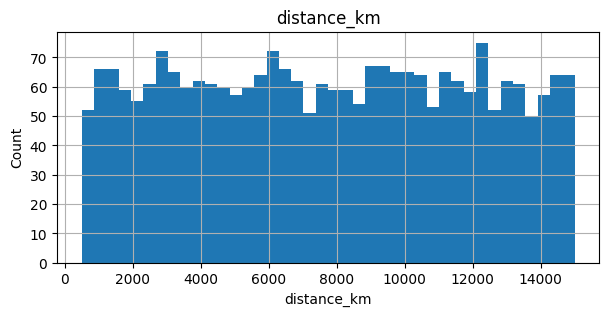

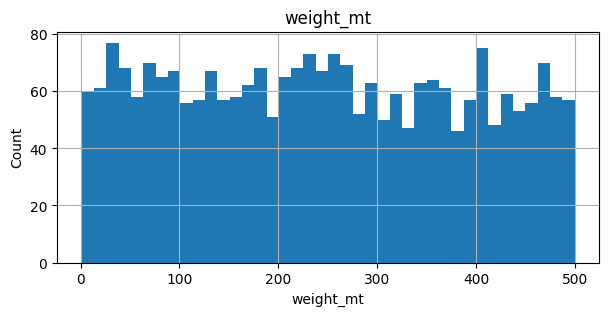

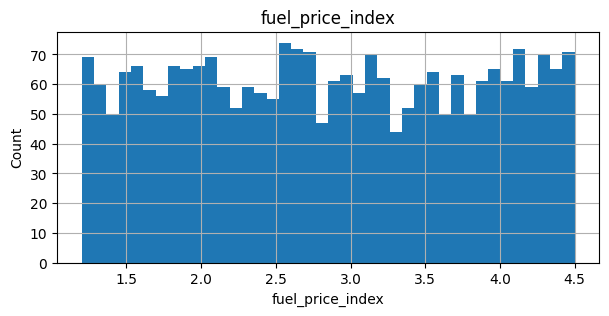

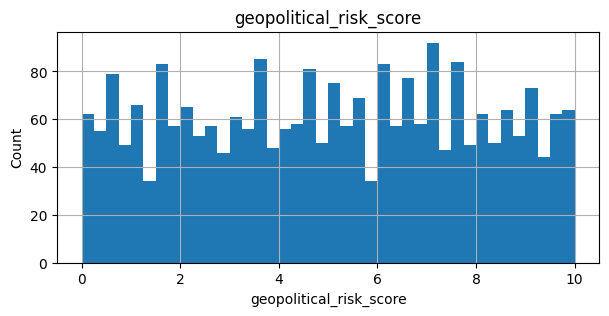

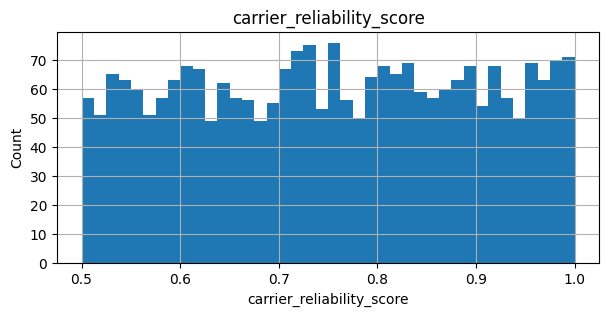

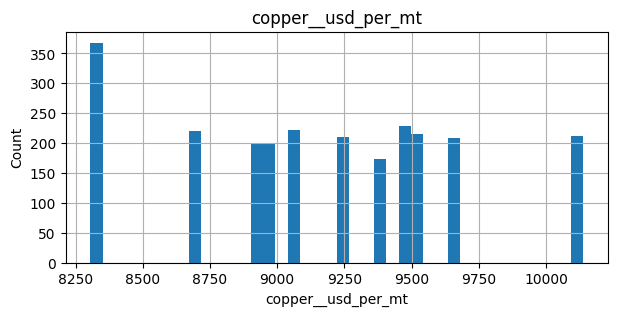

In [11]:
for col in NUMERIC_FEATURES:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.show()

,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,carrier_reliability_score,copper__usd_per_mt,lead_time_days
distance_km,1.000,0.009,-0.014,0.003,0.002,0.006,0.417
weight_mt,0.009,1.000,-0.029,-0.003,0.027,0.044,0.006
fuel_price_index,-0.014,-0.029,1.000,0.012,-0.048,0.001,-0.002
geopolitical_risk_score,0.003,-0.003,0.012,1.000,0.016,-0.009,0.094
carrier_reliability_score,0.002,0.027,-0.048,0.016,1.000,-0.002,0.003
copper__usd_per_mt,0.006,0.044,0.001,-0.009,-0.002,1.000,-0.009
lead_time_days,0.417,0.006,-0.002,0.094,0.003,-0.009,1.000


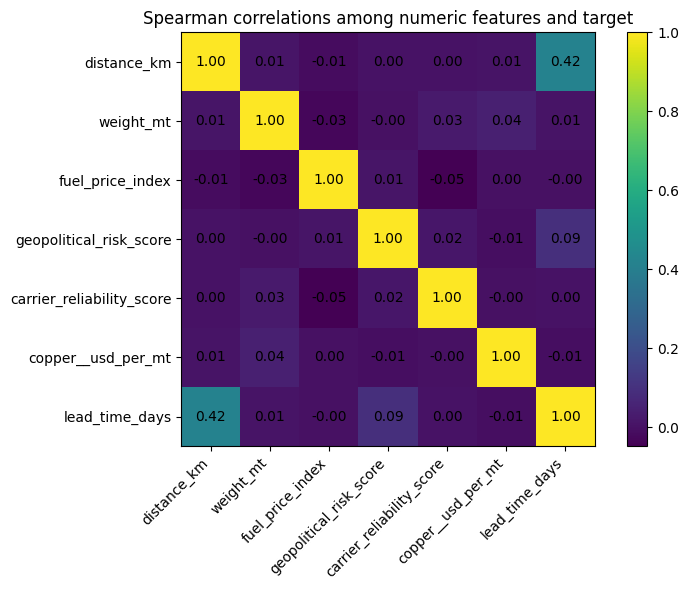

In [12]:
corr_cols = NUMERIC_FEATURES + [TARGET]
spearman_corr = df[corr_cols].corr(method="spearman")

display(spearman_corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(spearman_corr)

ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{spearman_corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
ax.set_title("Spearman correlations among numeric features and target")
plt.tight_layout()
plt.show()

**Interpretation.** Numeric features have plausible ranges and no missing values. No numeric outlier removal, winsorization, or log transformation is applied in version 1. Standard scaling is handled inside the modeling pipeline.

## 5. Categorical feature check

Check category counts and target summaries by category. Categories are kept as text and encoded inside the modeling pipeline.

In [13]:
for col in CATEGORICAL_FEATURES:
    print(f"Category counts for {col}")
    display(df[col].value_counts(dropna=False).to_frame("count"))

Category counts for origin_port


,count
origin_port,
Busan,336
Shanghai,330
Rotterdam,314
Los Angeles,314
Dubai,304
Antwerp,290
Hamburg,284
Singapore,283


Category counts for destination_port


,count
destination_port,
Marseille,288
Dubai,284
Rotterdam,280
Shanghai,276
Los Angeles,273
Antwerp,272
Busan,271
Singapore,264
Hamburg,247


Category counts for transport_mode


,count
transport_mode,
Air,653
Sea,629
Rail,589
Road,584


Category counts for product_category


,count
product_category,
Textiles,513
Pharmaceuticals,499
Automotive,483
Electronics,482
Perishables,478


Category counts for weather_condition


,count
weather_condition,
Fog,510
Hurricane,497
Rain,495
Clear,479
Storm,474


In [14]:
for col in CATEGORICAL_FEATURES:
    print(f"Target summary by {col}")
    display(categorical_target_summary(df, col, TARGET))

Target summary by origin_port


,count,mean,median,std,min,max
origin_port,,,,,,
Busan,336,20.079940,8.085,31.660567,0.5,222.48
Shanghai,330,20.250697,9.215,31.895111,0.5,234.84
Los Angeles,314,17.088981,7.265,29.608077,0.5,220.25
Rotterdam,314,20.307102,8.565,31.907670,0.5,231.26
Dubai,304,17.877171,8.095,29.938750,0.5,218.00
Antwerp,290,18.734552,8.565,27.840967,0.5,188.68
Hamburg,284,18.837254,9.265,27.764063,0.5,186.22
Singapore,283,18.368481,7.810,27.593122,0.5,167.07


Target summary by destination_port


,count,mean,median,std,min,max
destination_port,,,,,,
Marseille,288,21.161042,8.935,32.038414,0.5,220.25
Dubai,284,19.298063,8.490,30.301814,0.5,188.68
Rotterdam,280,19.794964,7.955,32.708309,0.5,199.13
Shanghai,276,17.824928,7.920,27.078528,0.5,185.62
Los Angeles,273,17.652381,7.940,28.503750,0.5,202.42
Antwerp,272,16.455074,7.590,25.234384,0.5,162.17
Busan,271,20.598635,8.580,30.766134,0.5,218.00
Singapore,264,20.870758,7.395,35.598807,0.5,234.84
Hamburg,247,16.855911,8.870,24.790806,0.5,222.48


Target summary by transport_mode


,count,mean,median,std,min,max
transport_mode,,,,,,
Air,653,1.697412,0.91,1.823081,0.50,8.58
Sea,629,37.882591,21.77,44.760011,1.06,234.84
Rail,589,19.784890,11.67,21.676729,0.50,117.76
Road,584,17.119589,9.74,20.132181,0.50,102.30


Target summary by product_category


,count,mean,median,std,min,max
product_category,,,,,,
Textiles,513,20.166394,8.07,31.226617,0.5,222.48
Pharmaceuticals,499,19.498016,9.02,28.414682,0.5,220.25
Automotive,483,18.220870,7.73,28.634486,0.5,187.31
Electronics,482,17.935021,7.99,28.682745,0.5,234.84
Perishables,478,18.969603,7.86,32.414780,0.5,231.26


Target summary by weather_condition


,count,mean,median,std,min,max
weather_condition,,,,,,
Fog,510,10.059549,6.94,10.253837,0.5,43.72
Hurricane,497,50.477626,37.32,50.426144,0.5,234.84
Rain,495,7.809697,6.27,7.399066,0.5,34.53
Clear,479,6.425825,4.81,6.203371,0.5,28.55
Storm,474,19.886456,16.79,18.599335,0.5,85.02


**Interpretation.** Categorical features have sufficient category counts for a first model version. They are kept as text and encoded with `OneHotEncoder(handle_unknown="ignore")` inside the modeling pipeline. No manual integer encoding and no rare-category grouping are applied.

## 6. Date and split feasibility check

Check whether a chronological development/test split is feasible. The `date` variable is used for splitting only and is not used as a model feature.

,date
min,2024-01-01
max,2024-12-31


,n_shipments
month_label,
2024-01,173
2024-02,195
2024-03,220
2024-04,229
2024-05,211
2024-06,208
2024-07,174
2024-08,199
2024-09,210


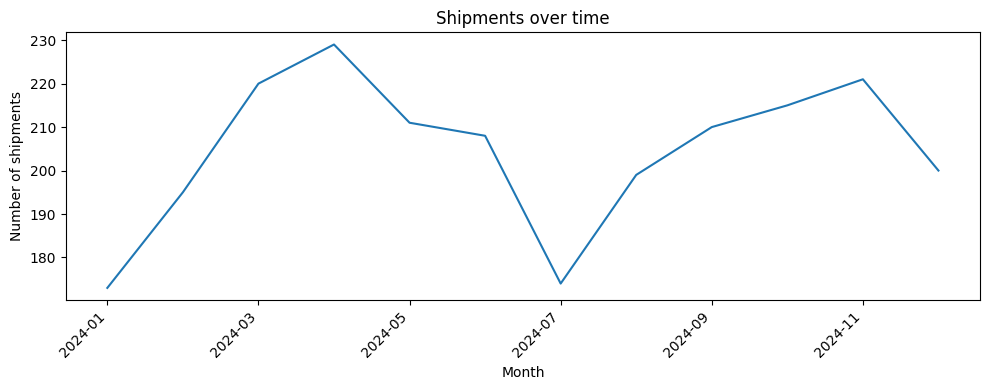

In [15]:
date_summary = df["date"].agg(["min", "max"])
display(date_summary.to_frame("date"))

monthly_counts = (
    df.assign(month_label=df["date"].dt.to_period("M").astype(str))
    .groupby("month_label")
    .size()
    .to_frame("n_shipments")
)

display(monthly_counts)

fig, ax = plt.subplots(figsize=(10, 4))
monthly_counts["n_shipments"].plot(ax=ax)
ax.set_xlabel("Month")
ax.set_ylabel("Number of shipments")
ax.set_title("Shipments over time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    modeling_config = yaml.safe_load(f)

data_config = modeling_config.get("data", {}) or {}

test_start_date = data_config.get("test_start_date")

if test_start_date is None:
    raise KeyError(
        "Could not find test_start_date. Expected "
        "data.test_start_date in config/modeling.yaml."
    )

test_start_date = pd.to_datetime(test_start_date)
test_start_date

Timestamp('2024-10-01 00:00:00')

In [18]:
split_summary = split_summary_by_date(
    df=df,
    date_col="date",
    target_col=TARGET,
    test_start_date=test_start_date,
)

split_summary

,period,n_rows,date_min,date_max,target_mean,target_median
0,development,1819,2024-01-01,2024-09-30,19.101655,8.29
1,final_test,636,2024-10-01,2024-12-31,18.619167,7.93


**Interpretation.** A chronological validation setup is feasible. The modeling workflow uses the earlier development period for `TimeSeriesSplit` model selection and the later holdout period for final test evaluation. The `date` and `month` columns are not model features.

## 7. Final EDA decisions for version 1

* **Target:** Use `lead_time_days`. The target has no missing or non-positive values. Long delays are plausible and operationally relevant, so all target values are kept. No IQR outlier removal, winsorization, or target transformation is applied.

* **Numeric features:** Use `distance_km`, `weight_mt`, `fuel_price_index`, `geopolitical_risk_score`, `carrier_reliability_score`, and `copper__usd_per_mt`. Ranges are plausible and required values are complete. Numeric scaling is handled inside the modeling pipeline, mainly for Ridge regression.

* **Categorical features:** Use `origin_port`, `destination_port`, `transport_mode`, `product_category`, and `weather_condition`. Categories are kept as text and encoded in the pipeline with `OneHotEncoder(handle_unknown="ignore")`. No manual encoding or rare-category grouping is applied.

* **Excluded columns:** Exclude `shipment_id`, `date`, `month`, `lead_time_days`, and `disruption_occurred`. `date` is used only for chronological splitting. `month` was used for SQL joining/temporal structure. `disruption_occurred` is excluded as likely leakage or outcome-like information.

* **Validation design:** This is shipment-level tabular regression, not time-series forecasting. Version 1 uses a chronological final holdout set based on `data.test_start_date` and `TimeSeriesSplit` on the development period for model selection.
